In [3]:
import boto3
import json
import pandas as pd
from tqdm import tqdm
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


# === Load Economic Data ===
def load_economic_data(filepath):
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["Date"])  # Ensure Date is in datetime format
    return df

# === Load Daily Fed Funds Target Rate Data ===
def load_fed_funds_data(filepath):
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["Date"])  # Ensure Date is in datetime format
    return df

# load data
economic_df = load_economic_data("Data_cleaned.csv")
fed_funds_df = load_fed_funds_data("Monthly_Fed_Funds_Target.csv")

In [4]:
# 📋 List of Prompt Variants to Test with Claude
prompt_variants = [
    # Style 1 – Analyst
    """
    You are an experienced financial analyst. Use the past {n} months of U.S. macroeconomic indicators to forecast the Federal Funds Target Rate for {target_date}.
    In addition, please only use your knowledge up to the target date of prediction.

    Please respond in valid JSON with the following fields:
    {{
      "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
    }}

    {data_table}
    """,

    # Style 2 – Central Bank Advisor
    """
    As an AI central bank advisor, review the past {n} months of U.S. economic data and predict the Fed Funds Target Rate the FOMC is likely to set on {target_date}.
    In addition, please only use your knowledge up to the target date of prediction.
   Please respond in valid JSON with the following fields:
    {{
      "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
    }}

    {data_table}
    """,

    # Style 3 – Quantitative Model
    """
    Using the structured economic data below from the past {n} months, estimate the Fed Funds Target Rate for {target_date}. Focus on trends in inflation, labor market conditions, and money supply.
    In addition, please only use your knowledge up to the target date of prediction.
    Please respond in valid JSON with the following fields:
    {{
      "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
    }}

    {data_table}
    """,

    # Style 4 – Policy Simulation
    """
    Simulate a Federal Reserve policy discussion. Given the following economic indicators from the last {n} months, what decision is most likely regarding the Fed Funds Rate on {target_date}?
    In addition, please only use your knowledge up to the target date of prediction.
    Please respond in valid JSON with the following fields:
    {{
      "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
    }}

    {data_table}
    """,

    # Style 5 – Instructional Command
    """
    Predict the Federal Funds Target Rate decision for {target_date} based on this table of economic data from the last {n} months. Consider inflation, employment, and growth.
    In addition, please only use your knowledge up to the target date of prediction.
    Please respond in valid JSON with the following fields:
    {{
      "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
    }}

    {data_table}
    """
]


In [5]:
def format_prompt(data, target_date, n, template):
    """
    Formats the Claude prompt using the provided data.

    Parameters:
        data (DataFrame): The n months of economic data
        target_date (datetime): The prediction date
        n (int): Number of months used
        template (str): Optional custom prompt template with placeholders

    Returns:
        str: Full prompt string
    """
    data_table = data.to_markdown(index=False)

    if template is None:
        # Default fallback template
        template = f"""
You are an AI economist. Based on the past {n} months of U.S. macroeconomic data,
predict the Federal Funds Target Rate for {target_date.date()}.  

Respond in this JSON format:
{{
  "predicted_rate": "e.g. 5.25",
      "confidence": "e.g. 85%",
      "explanation": "Brief rationale, max 100 words"
}}

{data_table}
"""
    else:
        template = template.format(n=n, target_date=str(target_date), data_table=data_table)

    return template


In [43]:
def search_best_prompt_variants(prompt_variants, economic_df, fed_funds_df, n=6):
    import pandas as pd
    from tqdm.notebook import tqdm

    results_summary = []
    all_predictions = {}

    test_dates = fed_funds_df['Date'].sort_values().unique()

    for i, prompt_template in enumerate(tqdm(prompt_variants, desc='🔎 Prompt Variants')):
        prompt_id = f"Prompt_{i+1}"
        total_error = 0
        predictions = []

        print(f"\n🧠 Generating predictions for {prompt_id}...")

        for date in tqdm(test_dates, leave=False, desc=f"📅 Dates for {prompt_id}"):
            try:
                actual_row = fed_funds_df[fed_funds_df['Date'] == date]
                if actual_row.empty:
                    continue
                actual_rate = actual_row.iloc[0]['Target_Rate']

                past_data = economic_df[economic_df['Date'] < date].sort_values("Date", ascending=False)
                filtered_data = past_data.head(n)
                if filtered_data.empty:
                    print(f"⚠️ Not enough history for {date}, skipping.")
                    continue

                prompt = format_prompt(filtered_data, date, n, template=prompt_template)
                response = query_claude_aws(prompt)

                # Clean and validate prediction
                raw_prediction = response.get("predicted_rate", "").replace('%', '').strip()
                try:
                    predicted = float(raw_prediction)
                except ValueError:
                    print(f"❌ Skipping {prompt_id} on {date} — non-numeric predicted_rate: '{raw_prediction}'")
                    continue

                confidence = response.get("confidence", "0").replace('%', '').strip()
                try:
                    confidence_val = float(confidence) / 100 if confidence else 0.5
                except ValueError:
                    confidence_val = 0.5

                margin = (1 - confidence_val) * 1.5
                lower = predicted - margin
                upper = predicted + margin
                explanation = response.get("explanation", "")

                error = abs(predicted - actual_rate)
                total_error += error

                predictions.append({
                    "Date": date,
                    "Actual": actual_rate,
                    "Predicted": predicted,
                    "Confidence": confidence,
                    "Lower": lower,
                    "Upper": upper,
                    "Explanation": explanation
                })

            except Exception as e:
                print(f"❌ Error generating prediction for {prompt_id} on {date}: {e}")
                continue

        # Store and save predictions
        df_predictions = pd.DataFrame(predictions)
        all_predictions[prompt_id] = df_predictions

        if df_predictions.empty:
            print(f"⚠️ No predictions saved for {prompt_id}. Skipping CSV save.")
        else:
            df_predictions.to_csv(f"Claude_{prompt_id}_Predictions.csv", index=False)
            print(f"✅ Saved {prompt_id} predictions with {len(df_predictions)} rows.")

        avg_error = total_error / len(predictions) if predictions else float('inf')
        results_summary.append({
            "Prompt Index": i + 1,
            "Avg Error": avg_error,
            "Prompt": prompt_template
        })

    summary_df = pd.DataFrame(results_summary).sort_values("Avg Error")
    return summary_df, all_predictions


In [44]:

def plot_prompt_predictions(all_predictions, summary_df, top_n=3):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    top_prompt_keys = [f"Prompt_{i}" for i in summary_df["Prompt Index"].head(top_n)]

    if top_prompt_keys:
        actuals = all_predictions[top_prompt_keys[0]]["Actual"]
        dates = all_predictions[top_prompt_keys[0]]["Date"]
        plt.plot(dates, actuals, label="Actual", color="black", linewidth=2)

    for key in top_prompt_keys:
        df = all_predictions[key]
        plt.plot(df["Date"], df["Predicted"], label=f"{key}")
        plt.fill_between(df["Date"], df["Lower"], df["Upper"], alpha=0.2)

    plt.title("Actual vs Predicted Fed Funds Rates (Top Prompts) with Confidence Bands")
    plt.xlabel("Date")
    plt.ylabel("Fed Funds Rate (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [6]:
def query_claude_aws(prompt, model_id="anthropic.claude-3-5-sonnet-20240620-v1:0", max_tokens=500):
    bedrock = boto3.client("bedrock-runtime")

    body = {
        "anthropic_version": "bedrock-2023-05-31",
        "max_tokens": max_tokens,
        "temperature": 0.5,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    }

    response = bedrock.invoke_model(
        modelId=model_id,
        body=json.dumps(body),
        contentType="application/json",
        accept="application/json"
    )

    response_body = json.loads(response["body"].read())
    message_content = response_body["content"][0]["text"]

    try:
        # Try to parse the returned JSON text
        parsed_response = json.loads(message_content)
        return parsed_response
    except json.JSONDecodeError:
        # If parsing fails, return raw text in a fallback format
        return {
            "predicted_rate": "Unknown",
            "confidence": "Unknown",
            "explanation": message_content[:200] + "..."  # truncate long response
        }


In [9]:
# 🔮 Latest Claude Prediction (Single Query)

# Get the most recent date from the Fed data
# latest_date = fed_funds_df["Date"].max()
latest_date = economic_df["Date"].max()
n_months = 6

# Pull latest N months of data before the prediction date
recent_data = economic_df[economic_df["Date"] < latest_date].sort_values("Date", ascending=False).head(n_months)

# 📝 Custom prompt for this cell 
custom_prompt_template = """
As an AI central bank advisor, review the past {n} months of U.S. economic data and predict the Fed's decision of increase, decrease, or hold the current fed rate on {target_date}.
In addition, please only use your knowledge up to the date of prediction. Additionally, it is worth noting that trade tensions have escalated, with greater uncertainty of 
possible tariffs set by the US to all of its trading partners. 

Please respond in valid JSON with the following fields:
{{
  "decision": "e.g. increase, decrease, unchanged"
  "confidence": "e.g. 85%",
  "explanation": "rationale of your prediction, max 100 words"
}}

{data_table}
"""

# Format the prompt using the custom version
latest_prompt = format_prompt(recent_data, latest_date, n_months, template=custom_prompt_template)

# Run single query to Claude
latest_prediction = query_claude_aws(latest_prompt)

# Display the results
# print("🧠 Claude Prediction for", latest_date.date())
print("Direction:", latest_prediction.get("decision", "N/A"))
# print("Predicted Rate:", latest_prediction.get("predicted_rate", "N/A"))
print("Confidence:", latest_prediction.get("confidence", "N/A"))
print("Explanation:", latest_prediction.get("explanation", "No explanation provided."))


Direction: unchanged
Confidence: 70%
Explanation: Based on recent data, inflation appears to be moderating but remains above target. Unemployment is low and stable. GDP growth is slowing but positive. The Fed may hold rates to balance inflation control with economic growth concerns, especially given trade tensions. However, continued inflationary pressures could warrant further tightening if trends persist.


In [10]:
# 🚀 Run Prompt Evaluation
results_df, all_predictions = search_best_prompt_variants(prompt_variants, economic_df, fed_funds_df, n=6)

🔎 Prompt Variants:   0%|          | 0/5 [00:00<?, ?it/s]


🧠 Generating predictions for Prompt_1...


📅 Dates for Prompt_1:   0%|          | 0/112 [00:00<?, ?it/s]

✅ Saved Prompt_1 predictions with 112 rows.

🧠 Generating predictions for Prompt_2...


📅 Dates for Prompt_2:   0%|          | 0/112 [00:00<?, ?it/s]

...

✅ Saved Prompt_3 predictions with 112 rows.

🧠 Generating predictions for Prompt_4...


📅 Dates for Prompt_4:   0%|          | 0/112 [00:00<?, ?it/s]

❌ Skipping Prompt_4 on 2020-04-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-05-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-06-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-07-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-09-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-11-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2020-12-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2021-06-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_4 on 2021-12-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
✅ Saved Prompt_4 predictions with 103 rows.

🧠 Generating predictions for Prompt_5...


📅 Dates for Prompt_5:   0%|          | 0/112 [00:00<?, ?it/s]

❌ Skipping Prompt_5 on 2020-04-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-05-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-06-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-07-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-08-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-09-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-10-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
❌ Skipping Prompt_5 on 2020-11-01T00:00:00.000000000 — non-numeric predicted_rate: '0.00-0.25'
✅ Saved Prompt_5 predictions with 104 rows.


In [11]:
# Display top results
pd.set_option('display.max_colwidth', 180)
results_df.reset_index(drop=True).head(5)

,Prompt Index,Avg Error,Prompt
0,1,0.149152,\n You are an experienced financial analyst. Use the past {n} months of U.S. macroeconomic indicators to forecast the Federal Funds Target Rate for {target_date}.\n In ad...
1,2,0.151792,"\n As an AI central bank advisor, review the past {n} months of U.S. economic data and predict the Fed Funds Target Rate the FOMC is likely to set on {target_date}.\n In ..."
2,4,0.157476,"\n Simulate a Federal Reserve policy discussion. Given the following economic indicators from the last {n} months, what decision is most likely regarding the Fed Funds Rate ..."
3,5,0.162212,"\n Predict the Federal Funds Target Rate decision for {target_date} based on this table of economic data from the last {n} months. Consider inflation, employment, and growth..."
4,3,0.168884,"\n Using the structured economic data below from the past {n} months, estimate the Fed Funds Target Rate for {target_date}. Focus on trends in inflation, labor market condit..."


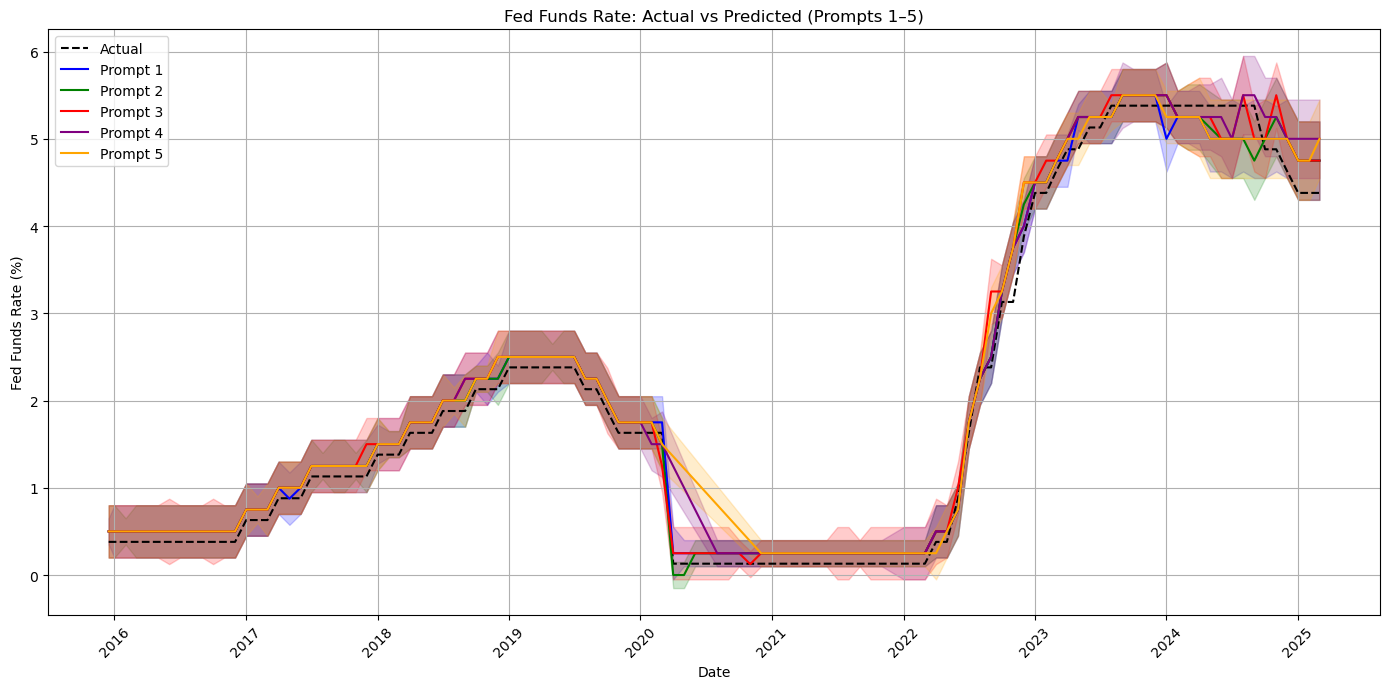


🔍 Prediction Accuracy (Lower is Better):
             MAE    RMSE
Prompt 1  0.1492  0.1737
Prompt 2  0.1518  0.1796
Prompt 4  0.1575  0.1934
Prompt 5  0.1622  0.1995
Prompt 3  0.1689  0.2131


In [12]:
# Define prompt files and labels
prompt_files = {
    "Prompt 1": "Claude_Prompt_1_Predictions.csv",
    "Prompt 2": "Claude_Prompt_2_Predictions.csv",
    "Prompt 3": "Claude_Prompt_3_Predictions.csv",
    "Prompt 4": "Claude_Prompt_4_Predictions.csv",
    "Prompt 5": "Claude_Prompt_5_Predictions.csv"
}

colors = {
    "Prompt 1": "blue",
    "Prompt 2": "green",
    "Prompt 3": "red",
    "Prompt 4": "purple",
    "Prompt 5": "orange"
}

plt.figure(figsize=(14, 7))
plotted_actual = False

accuracy_results = {}

# Loop through prompts
for label, filename in prompt_files.items():
    try:
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()
        df["Date"] = pd.to_datetime(df["Date"])
        df["Predicted"] = pd.to_numeric(df["Predicted"], errors="coerce")
        df["Lower"] = pd.to_numeric(df["Lower"], errors="coerce")
        df["Upper"] = pd.to_numeric(df["Upper"], errors="coerce")
        df["Actual"] = pd.to_numeric(df["Actual"], errors="coerce")

        df = df.dropna(subset=["Date", "Predicted", "Lower", "Upper", "Actual"])

        # Plot actual only once
        if not plotted_actual:
            plt.plot(df["Date"], df["Actual"], label="Actual", color="black", linestyle="--")
            plotted_actual = True

        # Plot prediction + confidence band
        plt.plot(df["Date"], df["Predicted"], label=label, color=colors[label])
        plt.fill_between(df["Date"], df["Lower"], df["Upper"], alpha=0.2, color=colors[label])

        # Calculate accuracy
        mae = mean_absolute_error(df["Actual"], df["Predicted"])
        rmse = np.sqrt(mean_squared_error(df["Actual"], df["Predicted"]))
        accuracy_results[label] = {"MAE": mae, "RMSE": rmse}

    except Exception as e:
        print(f"Error processing {label}: {e}")

# Final formatting
plt.title("Fed Funds Rate: Actual vs Predicted (Prompts 1–5)")
plt.xlabel("Date")
plt.ylabel("Fed Funds Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print accuracy comparison
print("\n🔍 Prediction Accuracy (Lower is Better):")
accuracy_df = pd.DataFrame(accuracy_results).T.sort_values("MAE")
print(accuracy_df.round(4))


In [46]:

n_simulations = 100
n = 6  # months of history
prompt_index = 1  # Prompt 2
prompt = prompt_variants[prompt_index]
test_dates = fed_funds_df["Date"].sort_values().unique()

all_runs = []


In [ ]:
for run in tqdm(range(n_simulations), desc="🔁 Simulating Prompt 2"):
    predictions = []

    for date in tqdm(test_dates, leave=False, desc=f"📅 Run {run+1}"):
        actual_row = fed_funds_df[fed_funds_df['Date'] == date]
        if actual_row.empty:
            continue
        actual_rate = actual_row.iloc[0]["Target_Rate"]

        past_data = economic_df[economic_df["Date"] < date].sort_values("Date", ascending=False)
        filtered_data = past_data.head(n)
        if filtered_data.empty:
            continue

        prompt_text = format_prompt(filtered_data, date, n, template=prompt)
        try:
            response = query_claude_aws(prompt_text)

            # Parse prediction
            raw_prediction = response.get("predicted_rate", "").replace("%", "").strip()
            predicted = float(raw_prediction)

            confidence = response.get("confidence", "").replace("%", "").strip()
            explanation = response.get("explanation", "").strip()

            predictions.append({
                "Date": date,
                "Actual": actual_rate,
                "Predicted": predicted,
                "Confidence": confidence,         # ✅ Added field
                "Explanation": explanation        # ✅ Added field
            })

        except Exception as e:
            print(f"❌ Run {run+1}, Date {date}: {e}")
            continue

    df_run = pd.DataFrame(predictions)
    all_runs.append(df_run)
    df_run.to_csv(f"Claude_Prompt_2_Simulation_{run+1}.csv", index=False)


🔁 Simulating Prompt 2:   0%|          | 0/100 [00:00<?, ?it/s]

📅 Run 1:   0%|          | 0/112 [00:00<?, ?it/s]

In [ ]:
# Combine all runs into one DataFrame
combined = pd.concat(all_runs)
combined["Date"] = pd.to_datetime(combined["Date"])

# Calculate average predictions by date
avg_df = combined.groupby("Date").agg({
    "Actual": "first",
    "Predicted": "mean"
}).reset_index()

# Save average results
avg_df.to_csv("Claude_Prompt_2_Average_Predictions.csv", index=False)



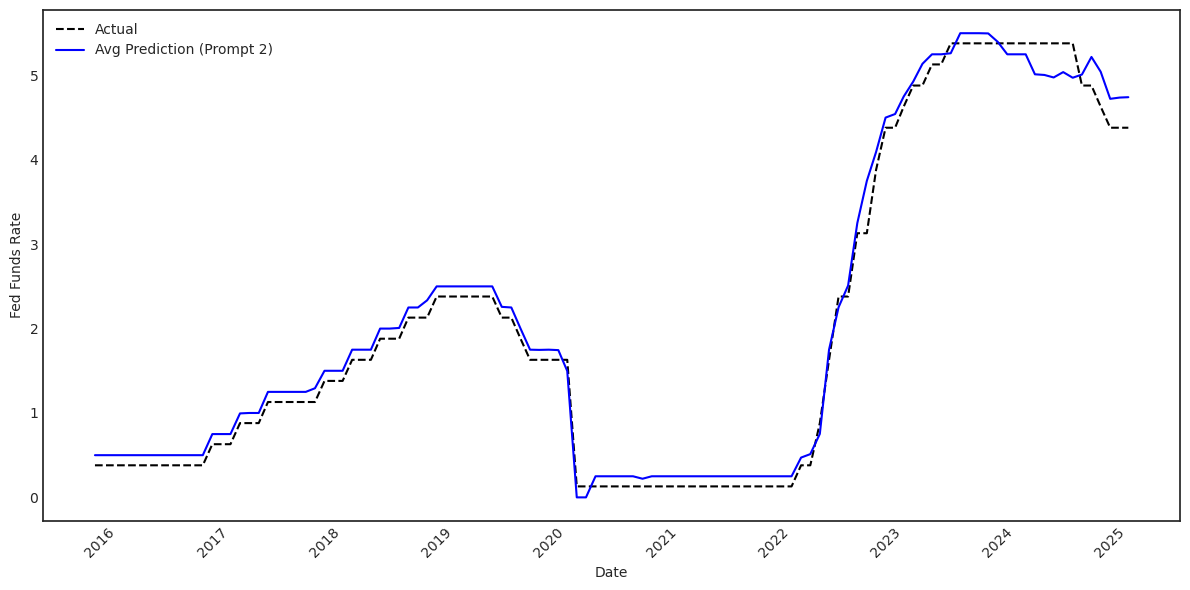

In [21]:
# Plot

plt.style.use('seaborn-v0_8-white')  
plt.figure(figsize=(12, 6))
plt.plot(avg_df["Date"], avg_df["Actual"], label="Actual", color="black", linestyle="--")
plt.plot(avg_df["Date"], avg_df["Predicted"], label="Avg Prediction (Prompt 2)", color="blue")
# plt.title("Average Prediction from 100 Simulations vs Actual Fed Funds Rate")
plt.xlabel("Date")
plt.ylabel("Fed Funds Rate")
plt.legend()
# plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figLLMvFed.png", dpi=300)
plt.show()


In [18]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [5]:
# New block: Load and process all saved simulations for error stats and visualization
import os
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Load all individual simulation results
simulation_files = [f for f in os.listdir() if f.startswith("Claude_Prompt_2_Simulation_") and f.endswith(".csv")]
all_runs = [pd.read_csv(f, parse_dates=["Date"]) for f in simulation_files]


In [6]:

# Step 2: Calculate MSE and RMSE per run
mae_list, mse_list, rmse_list = [], [], []
all_dates = sorted(set().union(*[df["Date"] for df in all_runs]))
actual_series = pd.concat(all_runs).groupby("Date")["Actual"].first().reindex(all_dates)

pred_matrix = []

for run_df in all_runs:
    run_df = run_df.set_index("Date").reindex(all_dates)
    pred = run_df["Predicted"]
    mask = pred.notna() & actual_series.notna()
    if mask.sum() > 0:
        mae = mean_absolute_error(actual_series[mask], pred[mask])
        mse = mean_squared_error(actual_series[mask], pred[mask])
        rmse = np.sqrt(mean_squared_error(actual_series[mask], pred[mask]))
        mae_list.append(mae)
        mse_list.append(mse)
        rmse_list.append(rmse)
        pred_matrix.append(pred.values)
    else:
        mae_list.append(np.nan)
        mse_list.append(np.nan)
        rmse_list.append(np.nan)




In [7]:
# Step 3: Output error summary
error_df = pd.DataFrame({"MAE": mae_list,"MSE": mse_list, "RMSE": rmse_list})
error_df.to_csv("FedFundsRate_Error.csv", index=False)
error_df_sum = error_df.describe(percentiles=[.1, .25, .5, .75, .9])
error_df_sum.to_csv("FedFundsRate_ErrorSummary.csv", index=False)
print("Summary Statistics of MAE, MSE and RMSE across all simulations:")
print(error_df.describe(percentiles=[.1, .25, .5, .75, .9]))

Summary Statistics of MAE, MSE and RMSE across all simulations:
              MAE         MSE        RMSE
count  100.000000  100.000000  100.000000
mean     0.148260    0.031144    0.176213
std      0.004520    0.003445    0.009672
min      0.139815    0.025002    0.158120
10%      0.142526    0.027410    0.165561
25%      0.145252    0.028622    0.169181
50%      0.147419    0.030754    0.175369
75%      0.151589    0.033439    0.182863
90%      0.154159    0.035545    0.188533
max      0.160648    0.040508    0.201267


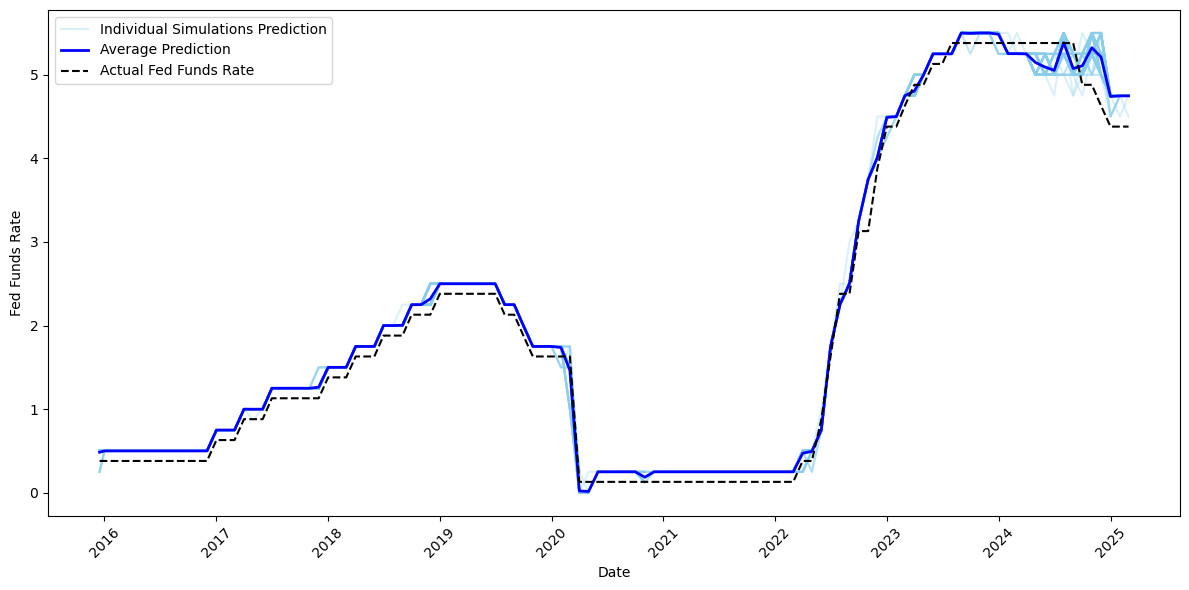

In [18]:
# Step 4: Plot predictions
pred_matrix_np = np.array(pred_matrix)
avg_preds = np.nanmean(pred_matrix_np, axis=0)

plt.figure(figsize=(12, 6))

# Plot one representative simulation for the legend
plt.plot(all_dates, pred_matrix_np[0], color='skyblue', alpha=0.3, label='Individual Simulations Prediction')
for sim in pred_matrix_np:
    plt.plot(all_dates, sim, color='skyblue', alpha=0.3)

plt.plot(all_dates, avg_preds, label="Average Prediction", color='blue', linewidth=2)
plt.plot(all_dates, actual_series.values, label="Actual Fed Funds Rate", color='black', linestyle='--')

plt.xlabel("Date")
plt.ylabel("Fed Funds Rate")
# plt.title("Simulated Forecasts vs Actual Fed Funds Rate")
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("FedFundsRate_Simulation_vs_Actual.png", dpi=300)
plt.show()
